# Statistical Methods in Imaging (SMI) Conference, 2026.
# Empowering Large Language Models with Statistics: A Practical Tutorial for Medical Imaging
**Ernest (Khashayar) Namdar, Dominik A. Deniffel, Pascal Tyrrell**

This notebook measures the predictive uncertainty of the Decoder LLM by applying perturbations (rephrasing) to the input text and observing the variance in the predicted probabilities.
For each radiology report, we prompt the LLM to generate a **summary** and an **improved writing version**. We then evaluate the probability of Acute Ischemic Stroke for all three versions and calculate the overall Uncertainty score.

In [2]:
import pandas as pd
import numpy as np
import torch
import gc
import os
from tqdm import tqdm
from transformers import AutoModelForCausalLM, AutoTokenizer
from sklearn.metrics import roc_auc_score
import matplotlib.pyplot as plt
import seaborn as sns

# ------------------------
# 1. Load Data
# ------------------------
ais_path = '../../Part2_Decoder_LLM_for_Classification/data/AIS.csv'
df = pd.read_csv(ais_path)
print(f"Loaded {len(df)} records.")


Loaded 3024 records.


In [3]:
# ------------------------
# 2. Model Loading
# ------------------------
model_id = "microsoft/MediPhi"
print(f"Loading {model_id}...")

tokenizer = AutoTokenizer.from_pretrained(model_id, trust_remote_code=True)
model = AutoModelForCausalLM.from_pretrained(
    model_id,
    device_map="cuda",
    torch_dtype="auto",
    trust_remote_code=True
)

yes_token_id = tokenizer.encode("yes", add_special_tokens=False)[0]
no_token_id = tokenizer.encode("no", add_special_tokens=False)[0]


Loading microsoft/MediPhi...


This model config has set a `rope_parameters['original_max_position_embeddings']` field, to be used together with `max_position_embeddings` to determine a scaling factor. Please set the `factor` field of `rope_parameters`with this ratio instead -- we recommend the use of this field over `original_max_position_embeddings`, as it is compatible with most model architectures.


Loading weights:   0%|          | 0/195 [00:00<?, ?it/s]

In [4]:
# ------------------------
# 3. Prompt Builders
# ------------------------
def build_summary_prompt(text):
    return f"""You are a medical AI assistant. Summarize the following radiology MRI report. Provide only the summary.\n\nReport:\n---\n{text}\n---\n\nSummary:"""

def build_improved_prompt(text):
    return f"""You are a medical AI assistant. Improve the writing of the following radiology MRI report. Provide only the improved report.\n\nReport:\n---\n{text}\n---\n\nImproved Report:"""

def build_classification_prompt(text):
    return f"""You are a medical AI assistant trained to classify radiology MRI reports.\nDetermine whether there is evidence of **acute ischemic stroke** in the following report.\nReply with a single word only: "yes" or "no".\n\nReport:\n---\n{text}\n---\n\nAnswer:"""


In [5]:
# ------------------------
# 4. Inference Logic
# ------------------------
def get_probability(text):
    prompt = build_classification_prompt(text)
    inputs = tokenizer(prompt, return_tensors="pt").to("cuda")
    with torch.no_grad():
        outputs = model(inputs.input_ids)
        # Extract logits for the next token
        next_token_logits = outputs.logits[0, -1, :]
        
    yes_logit = next_token_logits[yes_token_id].item()
    no_logit = next_token_logits[no_token_id].item()
    
    # Numerical stability for softmax
    max_logit = max(yes_logit, no_logit)
    yes_logit_exp = np.exp(yes_logit - max_logit)
    no_logit_exp = np.exp(no_logit - max_logit)
    
    prob_yes = yes_logit_exp / (yes_logit_exp + no_logit_exp)
    return prob_yes

def generate_text(prompt, max_new_tokens=150):
    inputs = tokenizer(prompt, return_tensors="pt").to("cuda")
    with torch.no_grad():
        outputs = model.generate(
            inputs.input_ids,
            max_new_tokens=max_new_tokens,
            do_sample=False,
            pad_token_id=tokenizer.eos_token_id
        )
    # Decode only the newly generated tokens
    generated_text = tokenizer.decode(outputs[0][inputs.input_ids.shape[1]:], skip_special_tokens=True).strip()
    return generated_text


In [6]:
# ------------------------
# 5. Evaluation Loop
# ------------------------
# Memory-optimized chunking to prevent GPU OOM
chunks = np.array_split(df, 10)
results = []

for i, chunk in enumerate(chunks):
    print(f"Processing chunk {i+1}/10...")
    for idx, row in tqdm(chunk.iterrows(), total=len(chunk)):
        original_text = row['Text']
        
        # 1. Generate perturbed text versions
        summary_text = generate_text(build_summary_prompt(original_text))
        improved_text = generate_text(build_improved_prompt(original_text))
        
        # 2. Get Probabilities
        prob_A = get_probability(original_text)
        prob_B = get_probability(summary_text)
        prob_C = get_probability(improved_text)
        
        mean_prob = (prob_A + prob_B + prob_C) / 3.0
        uncertainty = max(prob_A, prob_B, prob_C) - min(prob_A, prob_B, prob_C)
        
        results.append({
            'Id': row['ID'],
            'Original_Text': original_text,
            'Summary_Text': summary_text,
            'Improved_Text': improved_text,
            'Prob_Original': prob_A,
            'Prob_Summary': prob_B,
            'Prob_Improved': prob_C,
            'Mean_Prob': mean_prob,
            'Uncertainty': uncertainty,
            'Label': row['Label']
        })
        
    # Flush GPU memory caches
    torch.cuda.empty_cache()
    gc.collect()

res_df = pd.DataFrame(results)

# Save Results
os.makedirs('../../Part4_Uncertainty_Measurement/results', exist_ok=True)
save_path = '../../Part4_Uncertainty_Measurement/results/Rephrasing_Results.csv'
res_df.to_csv(save_path, index=False)
print(f"Saved results to {save_path}!")


/home/ernest/anaconda3/lib/python3.12/site-packages/numpy/_core/fromnumeric.py:57: FutureWarning: 'DataFrame.swapaxes' is deprecated and will be removed in a future version. Please use 'DataFrame.transpose' instead.
  return bound(*args, **kwds)


Processing chunk 1/10...


100%|██████████| 303/303 [38:51<00:00,  7.70s/it]


Processing chunk 2/10...


100%|██████████| 303/303 [38:24<00:00,  7.61s/it]


...

Processing chunk 9/10...


100%|██████████| 302/302 [36:00<00:00,  7.15s/it]


Processing chunk 10/10...


100%|██████████| 302/302 [36:27<00:00,  7.24s/it]


Saved results to ../../Part4_Uncertainty_Measurement/results/Rephrasing_Results.csv!


In [7]:
# ------------------------
# 6. Overall Metrics
# ------------------------
overall_auc = roc_auc_score(res_df['Label'], res_df['Mean_Prob'])
print(f"Overall ROC-AUC (Mean Probability): {overall_auc:.4f}")


Overall ROC-AUC (Mean Probability): 0.9803


/tmp/ipykernel_636362/1422655200.py:23: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=bin_labels, y=bin_aucs, palette="viridis")


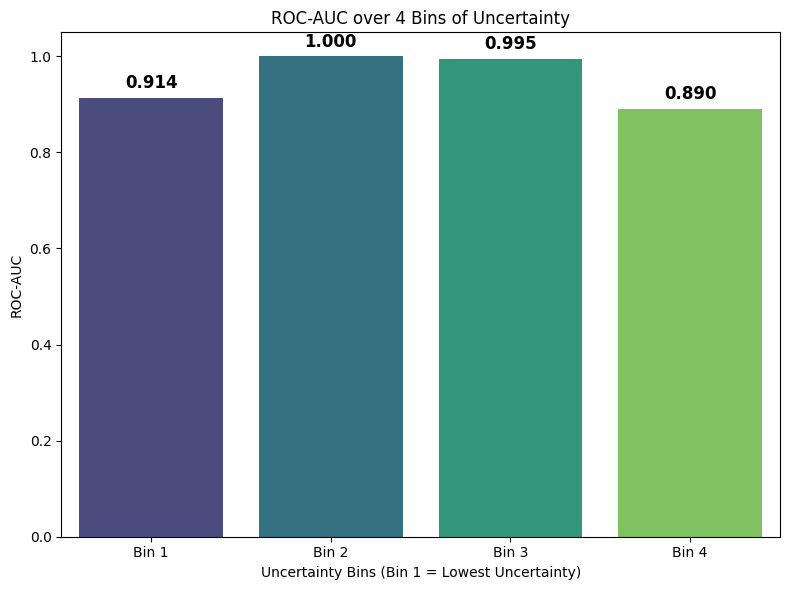

In [8]:
# ------------------------
# 7. Uncertainty Binning Analysis
# ------------------------
# Set the number of bins to subdivide the dataset
n_bins = 4

res_df = res_df.sort_values(by='Uncertainty').reset_index(drop=True)
res_df['Uncertainty_Bin'] = pd.qcut(res_df.index, q=n_bins, labels=[f"Bin {i+1}" for i in range(n_bins)])

bin_aucs = []
bin_labels = []

for b in res_df['Uncertainty_Bin'].unique():
    subset = res_df[res_df['Uncertainty_Bin'] == b]
    # Ensure there are both positive and negative cases in the bin before calculating AUC
    if len(subset['Label'].unique()) > 1:
        auc = roc_auc_score(subset['Label'], subset['Mean_Prob'])
        bin_aucs.append(auc)
        bin_labels.append(b)

# Plot the results
plt.figure(figsize=(8, 6))
sns.barplot(x=bin_labels, y=bin_aucs, palette="viridis")
plt.ylim(0, 1.05)
plt.title(f'ROC-AUC over {n_bins} Bins of Uncertainty')
plt.xlabel('Uncertainty Bins (Bin 1 = Lowest Uncertainty)')
plt.ylabel('ROC-AUC')

# Annotate bars with the exact AUC value
for i, v in enumerate(bin_aucs):
    plt.text(i, v + 0.02, f"{v:.3f}", ha='center', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.show()
